# Wine Quality Prediction

### AICTE Oasis Infobyte Internship – Data Analytics

**Name:** Rakshitha S  
**Task:** Wine Quality Prediction  
**Technology:** Python, Pandas, NumPy, Scikit-learn, Matplotlib, Jupyter Notebook

## Objective

The objective of this project is to predict wine quality based on its physicochemical properties.

The wine quality dataset contains chemical characteristics such as acidity, density, sulphates, and alcohol content. Three classification algorithms — Random Forest, SGD Classifier, and Support Vector Classifier (SVC) — are used to predict wine quality categories.

The models are evaluated and compared using accuracy, precision, recall, F1-score, and confusion matrices.

## Feature Selection

The chemical properties of wine are used as predictor variables because they describe the physicochemical characteristics of each wine.

The following features are used for classification:

- Fixed acidity
- Volatile acidity
- Citric acid
- Residual sugar
- Chlorides
- Free sulfur dioxide
- Total sulfur dioxide
- Density
- pH
- Sulphates
- Alcohol

The `Id` column is excluded because it is only an identifier and does not provide meaningful information for predicting wine quality.

## Dataset Overview

The dataset contains **1,143 wine records** and **13 columns**.

The dataset includes 11 physicochemical features, the original wine quality score, and an ID column.

There are no missing values in the dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.style.use("ggplot")

In [3]:
df = pd.read_csv("WineQT.csv")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [5]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [6]:
df['quality'].value_counts().sort_index()

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

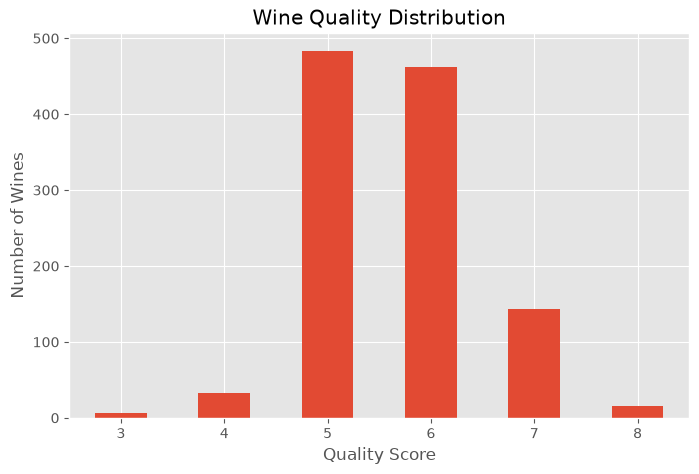

In [7]:
plt.figure(figsize=(8,5))

df['quality'].value_counts().sort_index().plot(kind='bar')

plt.title('Wine Quality Distribution')
plt.xlabel('Quality Score')
plt.ylabel('Number of Wines')
plt.xticks(rotation=0)
plt.show()

In [8]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


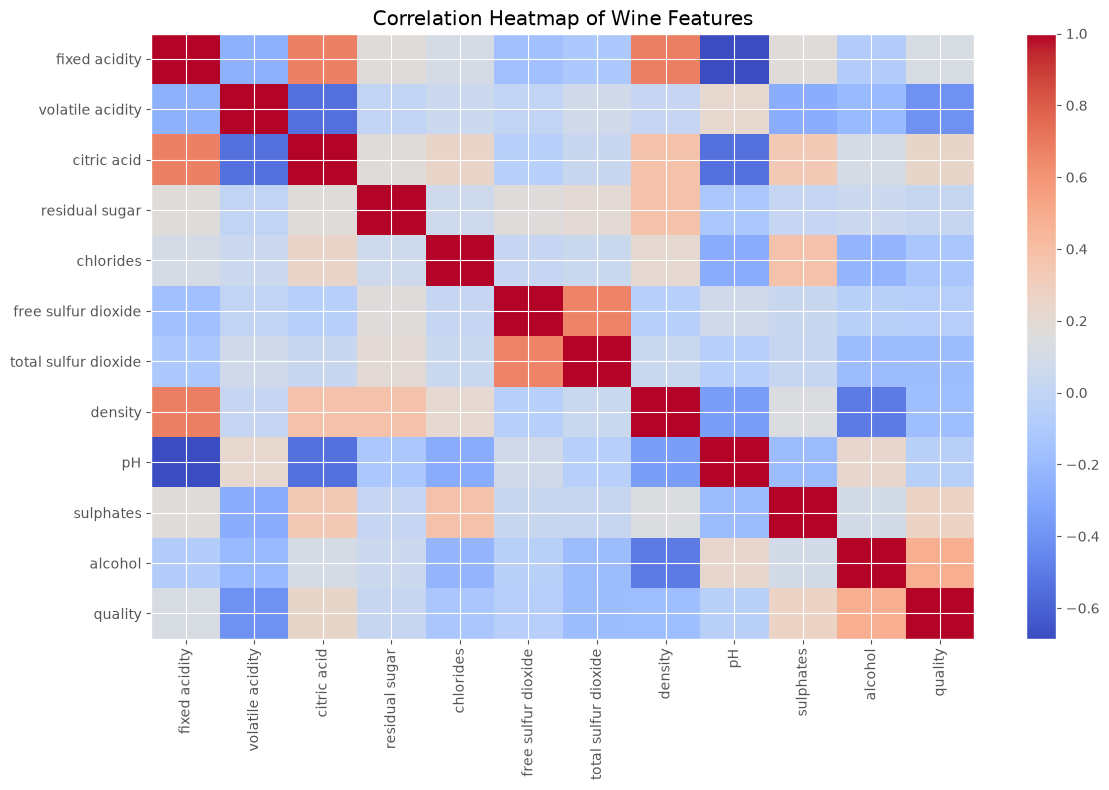

In [9]:
correlation = df.drop(columns=['Id']).corr()

plt.figure(figsize=(12, 8))
plt.imshow(correlation, cmap='coolwarm', aspect='auto')
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title('Correlation Heatmap of Wine Features')
plt.tight_layout()
plt.show()

In [10]:
def quality_category(score):
    if score <= 5:
        return 'Low'
    elif score == 6:
        return 'Medium'
    else:
        return 'High'

df['quality_category'] = df['quality'].apply(quality_category)

df['quality_category'].value_counts()

quality_category
Low       522
Medium    462
High      159
Name: count, dtype: int64

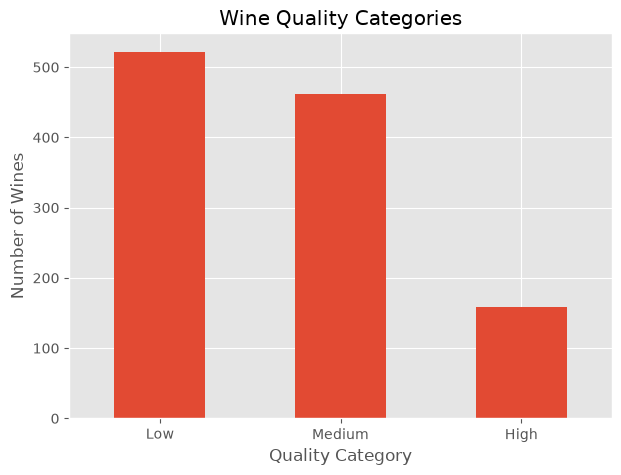

In [11]:
plt.figure(figsize=(7, 5))

df['quality_category'].value_counts().plot(kind='bar')

plt.title('Wine Quality Categories')
plt.xlabel('Quality Category')
plt.ylabel('Number of Wines')
plt.xticks(rotation=0)
plt.show()

In [12]:
X = df.drop(columns=['quality', 'quality_category', 'Id'])
y = df['quality_category']

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.value_counts())

Features:
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='str')

Target:
quality_category
Low       522
Medium    462
High      159
Name: count, dtype: int64


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 914
Testing samples: 229


In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature standardization completed.")

Feature standardization completed.


In [15]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [16]:
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.6855895196506551

Classification Report:
              precision    recall  f1-score   support

        High       0.75      0.66      0.70        32
         Low       0.73      0.73      0.73       105
      Medium       0.61      0.64      0.63        92

    accuracy                           0.69       229
   macro avg       0.70      0.68      0.69       229
weighted avg       0.69      0.69      0.69       229



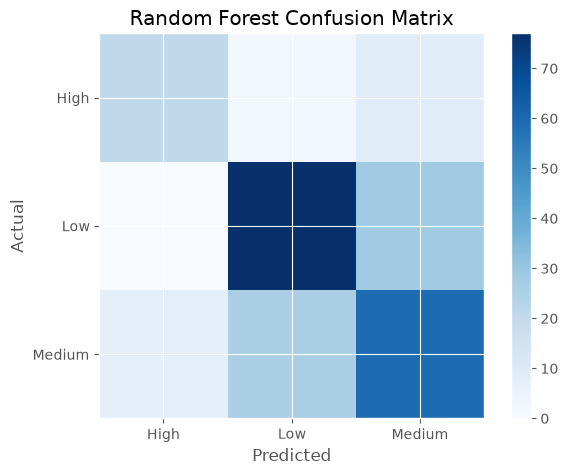

In [17]:
rf_cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(7, 5))
plt.imshow(rf_cm, cmap='Blues')
plt.colorbar()

plt.xticks(range(3), ['High', 'Low', 'Medium'])
plt.yticks(range(3), ['High', 'Low', 'Medium'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')

plt.show()

In [18]:
sgd_model = SGDClassifier(
    random_state=42,
    max_iter=1000,
    tol=1e-3
)

sgd_model.fit(X_train_scaled, y_train)

sgd_predictions = sgd_model.predict(X_test_scaled)

print("SGD Classifier trained successfully!")

SGD Classifier trained successfully!


In [19]:
sgd_accuracy = accuracy_score(y_test, sgd_predictions)

print("SGD Classifier Accuracy:", sgd_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, sgd_predictions))

SGD Classifier Accuracy: 0.5764192139737991

Classification Report:
              precision    recall  f1-score   support

        High       0.50      0.09      0.16        32
         Low       0.66      0.66      0.66       105
      Medium       0.50      0.65      0.57        92

    accuracy                           0.58       229
   macro avg       0.56      0.47      0.46       229
weighted avg       0.58      0.58      0.55       229



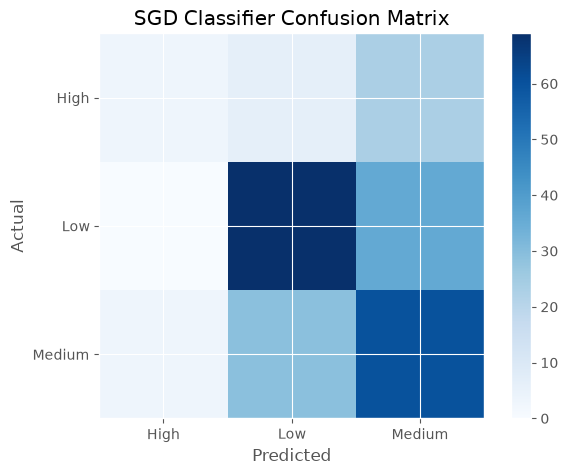

In [20]:
sgd_cm = confusion_matrix(y_test, sgd_predictions)

plt.figure(figsize=(7, 5))
plt.imshow(sgd_cm, cmap='Blues')
plt.colorbar()

plt.xticks(range(3), ['High', 'Low', 'Medium'])
plt.yticks(range(3), ['High', 'Low', 'Medium'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SGD Classifier Confusion Matrix')

plt.show()

In [21]:
svc_model = SVC(
    kernel='rbf',
    random_state=42
)

svc_model.fit(X_train_scaled, y_train)

svc_predictions = svc_model.predict(X_test_scaled)

print("SVC model trained successfully!")

SVC model trained successfully!


In [22]:
svc_accuracy = accuracy_score(y_test, svc_predictions)

print("SVC Accuracy:", svc_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, svc_predictions))

SVC Accuracy: 0.6462882096069869

Classification Report:
              precision    recall  f1-score   support

        High       0.62      0.31      0.42        32
         Low       0.73      0.75      0.74       105
      Medium       0.56      0.64      0.60        92

    accuracy                           0.65       229
   macro avg       0.64      0.57      0.59       229
weighted avg       0.65      0.65      0.64       229



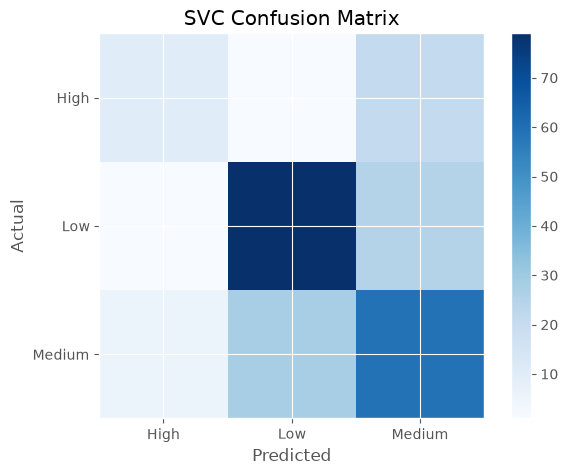

In [23]:
svc_cm = confusion_matrix(y_test, svc_predictions)

plt.figure(figsize=(7, 5))
plt.imshow(svc_cm, cmap='Blues')
plt.colorbar()

plt.xticks(range(3), ['High', 'Low', 'Medium'])
plt.yticks(range(3), ['High', 'Low', 'Medium'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVC Confusion Matrix')

plt.show()

In [24]:
model_comparison = pd.DataFrame({
    'Model': [
        'Random Forest',
        'SGD Classifier',
        'SVC'
    ],
    'Accuracy': [
        rf_accuracy,
        sgd_accuracy,
        svc_accuracy
    ]
})

model_comparison

,Model,Accuracy
0,Random Forest,0.685590
1,SGD Classifier,0.576419
2,SVC,0.646288


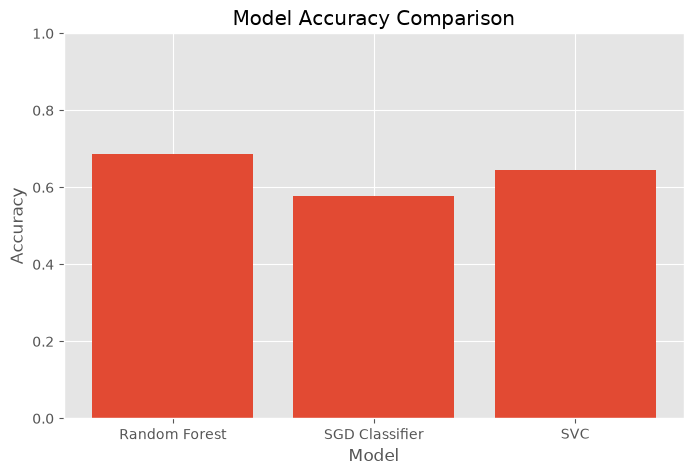

In [25]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison['Model'],
    model_comparison['Accuracy']
)

plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

plt.show()

In [26]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance


,Feature,Importance
10,alcohol,0.154021
9,sulphates,0.134324
1,volatile acidity,0.111090
6,total sulfur dioxide,0.094370
7,density,0.086762
2,citric acid,0.075107
8,pH,0.073241
0,fixed acidity,0.073119
4,chlorides,0.071907
5,free sulfur dioxide,0.063896


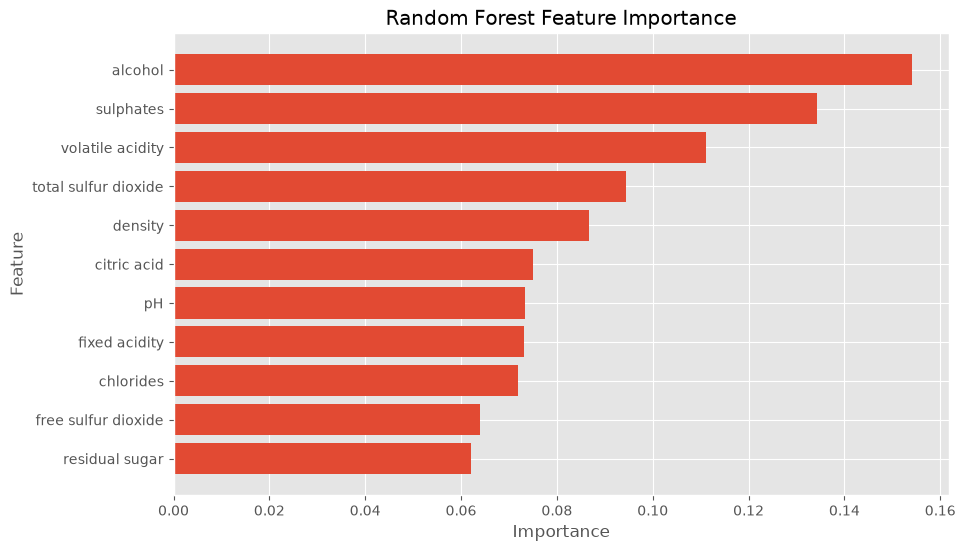

In [27]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')

plt.gca().invert_yaxis()

plt.show()

## Class Imbalance

The wine quality categories are not evenly distributed.

- Low quality: 522 wines
- Medium quality: 462 wines
- High quality: 159 wines

The High-quality category has considerably fewer samples than the Low and Medium categories. This class imbalance can make the machine learning models better at predicting the majority classes while making High-quality wines more difficult to classify.

Therefore, accuracy alone should not be used to judge model performance. Precision, recall, and F1-score should also be considered, especially for the underrepresented High-quality class.

## Feature Importance

The Random Forest feature importance analysis shows which chemical properties contribute most to the model's wine quality predictions.

The features with higher importance have a greater influence on the model's classification decisions. The feature importance chart helps identify the most useful chemical characteristics for predicting wine quality.

## Model Comparison

Three classification algorithms were trained and evaluated:

1. Random Forest
2. SGD Classifier
3. Support Vector Classifier (SVC)

Their accuracy scores were compared using a model comparison table and visualization. Classification reports were also examined to compare precision, recall, and F1-score across the three quality categories.

The model with the best overall performance can be considered the most suitable candidate for predicting wine quality in this dataset.

## Conclusion

This project developed a machine learning approach for predicting wine quality based on its physicochemical properties.

The dataset was inspected for missing values and class distribution, followed by exploratory analysis and correlation analysis. Wine quality scores were grouped into Low, Medium, and High categories for classification.

Three machine learning models — Random Forest, SGD Classifier, and SVC — were trained and evaluated. StandardScaler was used to standardize the features for the models that require scaled input.

The model comparison helps identify the most suitable classifier for this dataset. Feature importance from the Random Forest model also provides insight into which chemical properties are most useful for predicting wine quality.